In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
print("TensorFlow Version:", tf.__version__)
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print("\nDataset Information")
print("=" * 40)
print("Training images :", x_train.shape)
print("Training labels :", y_train.shape)
print("Testing images  :", x_test.shape)
print("Testing labels  :", y_test.shape)

TensorFlow Version: 2.20.0

Dataset Information
Training images : (60000, 28, 28)
Training labels : (60000,)
Testing images  : (10000, 28, 28)
Testing labels  : (10000,)


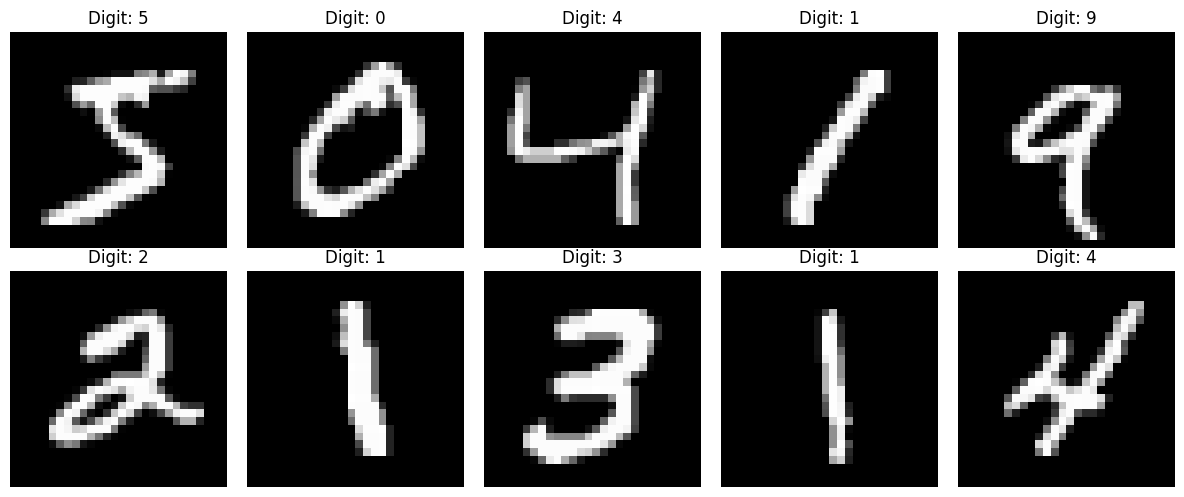

In [11]:
# STEP 2: DISPLAY SAMPLE IMAGES
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Digit: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [27]:
# STEP 3: IMAGE PREPROCESSING
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)
print("After preprocessing:")
print("Training images:", x_train.shape)
print("Testing images :", x_test.shape)

After preprocessing:
Training images: (60000, 28, 28, 1, 1)
Testing images : (10000, 28, 28, 1, 1)


In [13]:
# STEP 4: TRAINING AND VALIDATION SPLIT
validation_size = 5000
x_val = x_train[-validation_size:]
y_val = y_train[-validation_size:]
x_train_final = x_train[:-validation_size]
y_train_final = y_train[:-validation_size]
print("Training data  :", x_train_final.shape)
print("Validation data:", x_val.shape)
print("Testing data   :", x_test.shape)

Training data  : (55000, 28, 28, 1)
Validation data: (5000, 28, 28, 1)
Testing data   : (10000, 28, 28, 1)


In [14]:
# STEP 5: DESIGN THE CONVOLUTIONAL NEURAL NETWORK
model = models.Sequential([
    # Convolutional Layer 1
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),
    # Pooling Layer 1
    layers.MaxPooling2D(pool_size=(2, 2)),
    # Convolutional Layer 2
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    # Pooling Layer 2
    layers.MaxPooling2D(pool_size=(2, 2)),
    # Convert feature maps into 1D vector
    layers.Flatten(),
    # Fully Connected Layer
    layers.Dense(128, activation="relu"),
    # Dropout
    layers.Dropout(0.5),
    # Output Layer - 10 classes
    layers.Dense(10, activation="softmax")
])
# Display model architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# STEP 6: COMPILE AND TRAIN THE CNN
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
# Train the model
history = model.fit(
    x_train_final,
    y_train_final,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=128,
    verbose=1 )

Epoch 1/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 41s 91ms/step - accuracy: 0.9024 - loss: 0.3197 - val_accuracy: 0.9842 - val_loss: 0.0592
Epoch 2/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 40s 89ms/step - accuracy: 0.9717 - loss: 0.0947 - val_accuracy: 0.9876 - val_loss: 0.0430
Epoch 3/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 43s 93ms/step - accuracy: 0.9789 - loss: 0.0709 - val_accuracy: 0.9890 - val_loss: 0.0376
Epoch 4/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 43s 97ms/step - accuracy: 0.9824 - loss: 0.0570 - val_accuracy: 0.9912 - val_loss: 0.0300
Epoch 5/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 95s 128ms/step - accuracy: 0.9854 - loss: 0.0492 - val_accuracy: 0.9916 - val_loss: 0.0305
Epoch 6/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 65s 88ms/step - accuracy: 0.9873 - loss: 0.0416 - val_accuracy: 0.9902 - val_loss: 0.0327
Epoch 7/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 38s 89ms/step - accuracy: 0.9885 - loss: 0.0366 - val_accuracy: 0.9902 - val_loss: 0.0349
Epoch 8/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 39s 91ms/step - accuracy: 0.9900 - loss: 0.0330 -

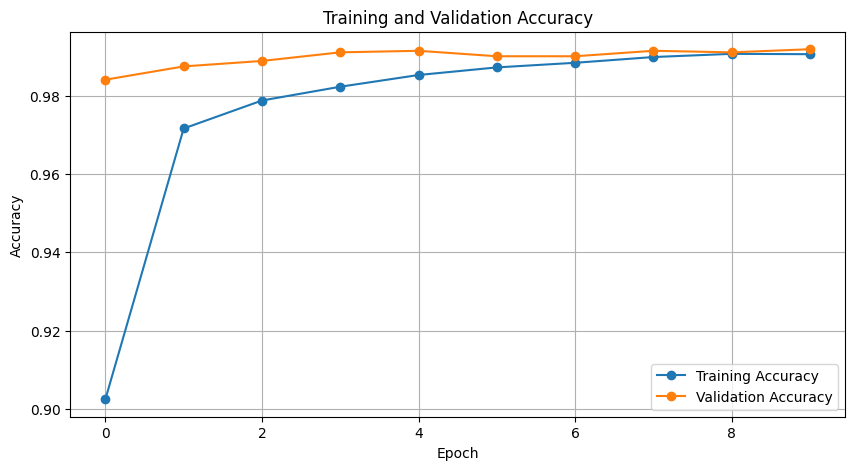

In [16]:
# STEP 7A: ACCURACY CURVE
plt.figure(figsize=(10, 5))
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy",
    marker="o"
)
plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    marker="o"
)
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

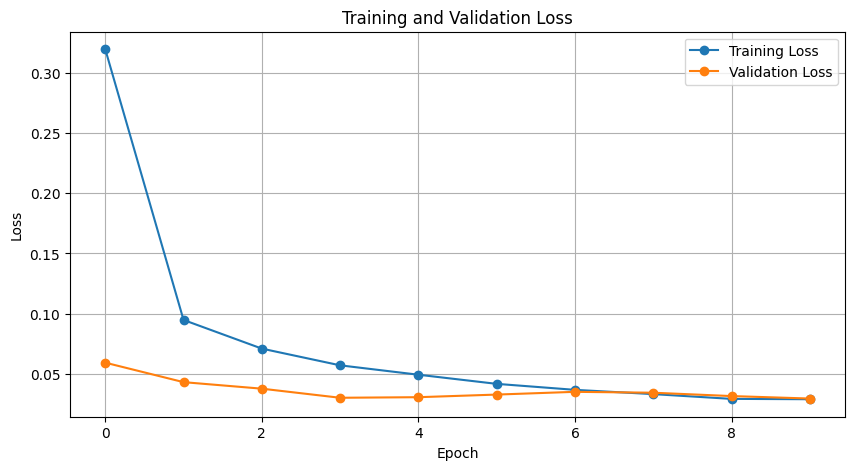

In [17]:
# STEP 7: LOSS CURVE
plt.figure(figsize=(10, 5))
plt.plot(
    history.history["loss"],
    label="Training Loss",
    marker="o"
)
plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    marker="o"
)
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

ACTUAL VS PREDICTED LABELS
Image 1: Actual = 7, Predicted = 7
Image 2: Actual = 2, Predicted = 2
Image 3: Actual = 1, Predicted = 1
Image 4: Actual = 0, Predicted = 0
Image 5: Actual = 4, Predicted = 4
Image 6: Actual = 1, Predicted = 1
Image 7: Actual = 4, Predicted = 4
Image 8: Actual = 9, Predicted = 9
Image 9: Actual = 5, Predicted = 5
Image 10: Actual = 9, Predicted = 9


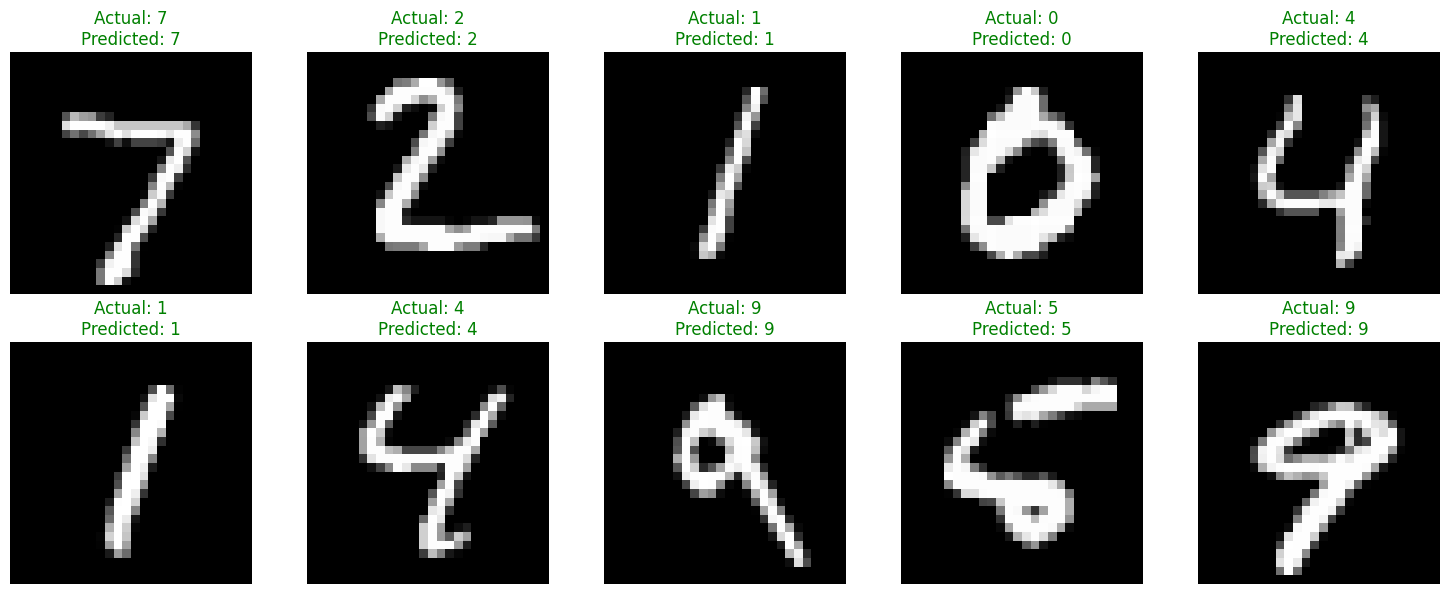

In [18]:
# STEP 8: PREDICTION ON UNSEEN TEST IMAGES
num_images = 10
test_images = x_test[:num_images]
actual_labels = y_test[:num_images]
# Generate predictions
prediction_probabilities = model.predict(
    test_images,
    verbose=0
)
predicted_labels = np.argmax(
    prediction_probabilities,
    axis=1
)
print("ACTUAL VS PREDICTED LABELS")
print("=" * 50)
for i in range(num_images):
    print(
        f"Image {i + 1}: "
        f"Actual = {actual_labels[i]}, "
        f"Predicted = {predicted_labels[i]}"
    )
# Display images
plt.figure(figsize=(15, 6))
for i in range(num_images):
    plt.subplot(2, 5, i + 1)
    plt.imshow(
        test_images[i].reshape(28, 28),
        cmap="gray"
    )
    # Green if correct, red if incorrect
    if actual_labels[i] == predicted_labels[i]:
        color = "green"
    else:
        color = "red"
    plt.title(
        f"Actual: {actual_labels[i]}\n"
        f"Predicted: {predicted_labels[i]}",
        color=color
    )
    plt.axis("off")
plt.tight_layout()
plt.show()

In [19]:
# Accuracy for the 10 displayed images
correct_predictions = np.sum(
    actual_labels == predicted_labels
)
incorrect_predictions = (
    num_images - correct_predictions
)
prediction_accuracy = (
    correct_predictions / num_images
) * 100
print("\nPrediction Summary")
print("=" * 40)
print("Total Images        :", num_images)
print("Correct Predictions :", correct_predictions)
print("Incorrect Predictions:", incorrect_predictions)
print(f"Accuracy            : {prediction_accuracy:.2f}%")


Prediction Summary
Total Images        : 10
Correct Predictions : 10
Incorrect Predictions: 0
Accuracy            : 100.00%


In [20]:
# STEP 9: MODEL EVALUATION
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)
print("TEST DATASET RESULTS")
print("=" * 50)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

TEST DATASET RESULTS
Test Loss     : 0.0199
Test Accuracy : 0.9939
Test Accuracy : 99.39%


In [21]:
# PERFORMANCE METRICS
test_probabilities = model.predict(
    x_test,
    verbose=0
)
test_predictions = np.argmax(
    test_probabilities,
    axis=1
)
# Calculate metrics
accuracy = accuracy_score(
    y_test,
    test_predictions
)
precision = precision_score(
    y_test,
    test_predictions,
    average="weighted"
)
recall = recall_score(
    y_test,
    test_predictions,
    average="weighted"
)
f1 = f1_score(
    y_test,
    test_predictions,
    average="weighted"
)
print("PERFORMANCE METRICS")
print("=" * 50)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

PERFORMANCE METRICS
Accuracy  : 0.9939
Precision : 0.9939
Recall    : 0.9939
F1-Score  : 0.9939


In [28]:
# CLASSIFICATION REPORT
print("CLASSIFICATION REPORT")
print("=" * 70)
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "Digit 0","Digit 1","Digit 2","Digit 3","Digit 4","Digit 5", "Digit 6", "Digit 7","Digit 8", "Digit 9" ]))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Digit 0       0.99      1.00      1.00       980
     Digit 1       1.00      1.00      1.00      1135
     Digit 2       1.00      1.00      1.00      1032
     Digit 3       0.99      0.99      0.99      1010
     Digit 4       1.00      0.99      1.00       982
     Digit 5       0.99      0.99      0.99       892
     Digit 6       1.00      0.99      1.00       958
     Digit 7       0.99      0.99      0.99      1028
     Digit 8       0.99      0.99      0.99       974
     Digit 9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



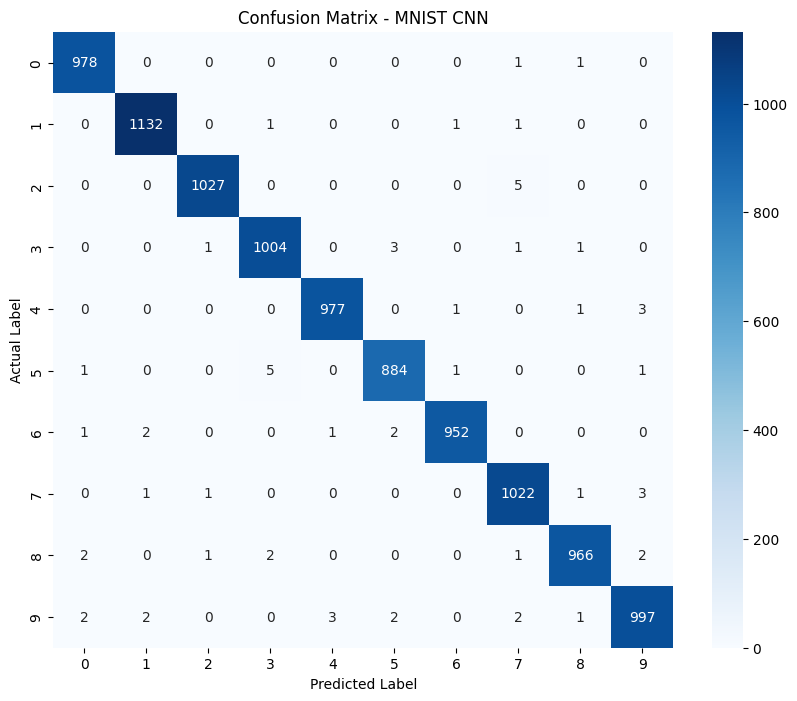

In [23]:
# CONFUSION MATRIX
cm = confusion_matrix(
    y_test,
    test_predictions
)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)
plt.title("Confusion Matrix - MNIST CNN")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

Total Misclassified Images: 61


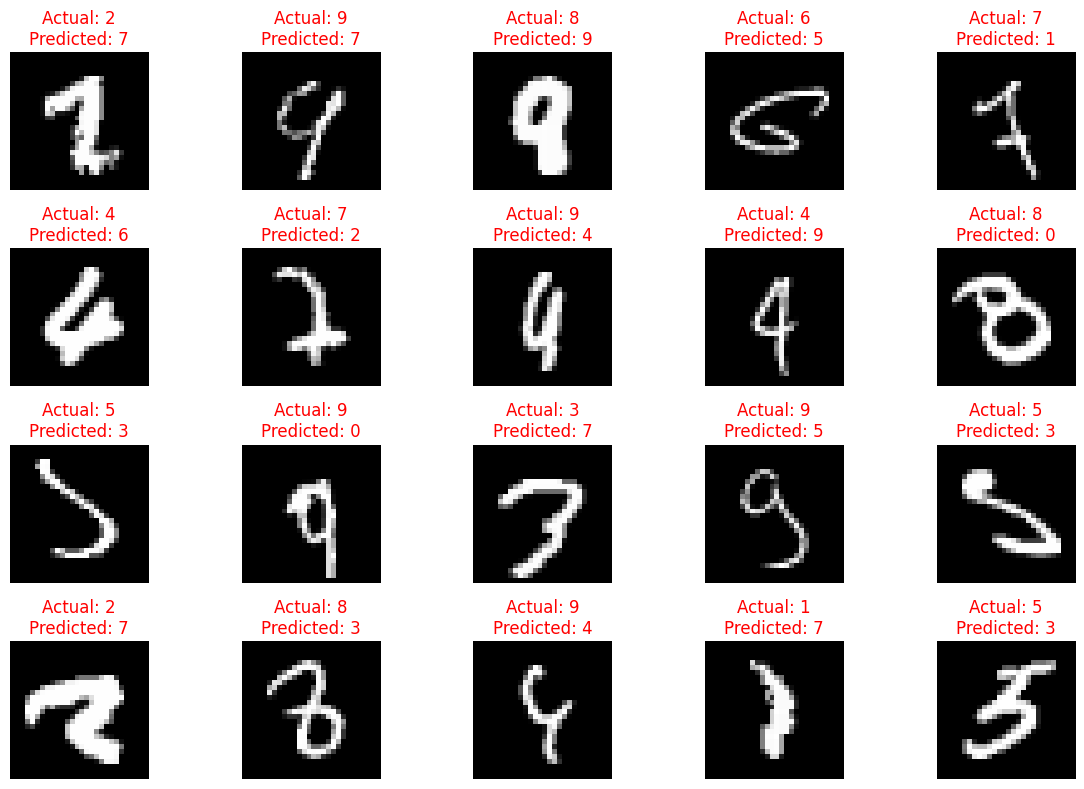

In [24]:
# Find indices of incorrectly classified images
incorrect_indices = np.where(
    test_predictions != y_test
)[0]
print("Total Misclassified Images:",
      len(incorrect_indices))
# Display first 20 misclassified images
plt.figure(figsize=(12, 8))
for i, index in enumerate(incorrect_indices[:20]):
    plt.subplot(4, 5, i + 1)
    plt.imshow(
        x_test[index].reshape(28, 28),
        cmap="gray"
    )
    plt.title(
        f"Actual: {y_test[index]}\n"
        f"Predicted: {test_predictions[index]}",
        color="red"
    )
    plt.axis("off")
plt.tight_layout()
plt.show()

In [25]:
# SAVE THE TRAINED MODEL
model.save("mnist_cnn_model.keras")
print("CNN model saved successfully!")
from google.colab import files
files.download("mnist_cnn_model.keras")

CNN model saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
print("=" * 60)
print("       CNN-BASED MNIST DIGIT CLASSIFICATION")
print("=" * 60)
print(f"Training Samples   : {len(x_train_final)}")
print(f"Validation Samples : {len(x_val)}")
print(f"Testing Samples    : {len(x_test)}")
print("-" * 60)
print(f"Test Loss          : {test_loss:.4f}")
print(f"Accuracy           : {accuracy * 100:.2f}%")
print(f"Precision          : {precision * 100:.2f}%")
print(f"Recall             : {recall * 100:.2f}%")
print(f"F1-Score           : {f1 * 100:.2f}%")
print("=" * 60)
print("CNN training and evaluation completed successfully.")

       CNN-BASED MNIST DIGIT CLASSIFICATION
Training Samples   : 55000
Validation Samples : 5000
Testing Samples    : 10000
------------------------------------------------------------
Test Loss          : 0.0199
Accuracy           : 99.39%
Precision          : 99.39%
Recall             : 99.39%
F1-Score           : 99.39%
CNN training and evaluation completed successfully.
